In [41]:
import pandas as pd
import numpy as np
import pickle
import os
import scipy.sparse
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE

In [42]:
# load dataset
df = pd.read_csv('../data/SYNAPSE.csv')

print("dataset info")
print(f"shape: {df.shape}")
print(f"\ndtypes:\n{df.dtypes.to_string()}")
print(f"\nmissing values:\n{df.isnull().sum().to_string()}")
print("\nfirst 3 rows:")
print(df.head(3).to_string())

dataset info
shape: (130637, 6)

dtypes:
Symptoms                object
Gender                  object
Age                     object
Duration                object
Severity                object
Final Recommendation    object

missing values:
Symptoms                0
Gender                  0
Age                     0
Duration                0
Severity                0
Final Recommendation    0

first 3 rows:
                                                                                                                                                             Symptoms  Gender            Age             Duration Severity Final Recommendation
0  Unwanted weight loss, Mouth sore, Persistent mouth pain, Lump thickening in lips, mouth, cheek, White red patch on gums, tongue, tonsil, mouth lining, sore throat    Male     6-15 years  Greater than 3 days   Severe  Doctor Consultation
1     Feeling tired, Shortness breath, Blue skin color, gray skin color, Trouble gaining weight, Irritabi

In [43]:
# split each comma-separated string and count unique individual symptoms
all_symptoms = df['Symptoms'].str.split(',').explode().str.strip().str.lower()
print(f"\nunique symptoms: {all_symptoms.nunique()}")
unique_symptoms = all_symptoms.unique()

print(sorted(unique_symptoms))


unique symptoms: 1808
['a cauliflower like shape caused by a few warts close together', 'a feeling of warmth on the affected leg', 'a feeling of weakness', 'a gritty feeling in eyes', 'a high temperature does not go away', 'a hoarse voice', 'a pause in breathing', 'a pause in breathing in babies', 'a pulsating throbbing feeling in your stomach area', 'a stiff neck', 'a white', 'abdominal bloating', 'abdominal burning', 'abdominal cramp', 'abdominal cramps', 'abdominal discomfort', 'abdominal distention', 'abdominal fullness', 'abdominal mass', 'abdominal pain', 'abdominal pressure', 'abdominal problems', 'abdominal tenderness', 'abnormal behavior', 'abnormal bleeding', 'abnormal breathing pattern', 'abnormal discharge from anus', 'abnormal discharge from genitals', 'abnormal eye movements', 'abnormal hair growth', 'abnormal penile discharge', 'abnormal pulse', 'abnormal sensation', 'abnormal skin color', 'abnormal vaginal bleeding', 'abnormal vaginal discharge', 'abscess', 'absence of

In [44]:
# analyse age column
print(df['Age'].value_counts())

Age
6-15 years        32300
below 5 years     31174
16-45 years       17653
above 45 years    17631
16-60 years       16604
above 60 years    15275
Name: count, dtype: int64


The dataset contains overlapping age brackets. Encoding needs to be done to accomodate this. "16-60 years" can be grouped with "16-45 years" at same ordinal value since both represent the working-age adult range.

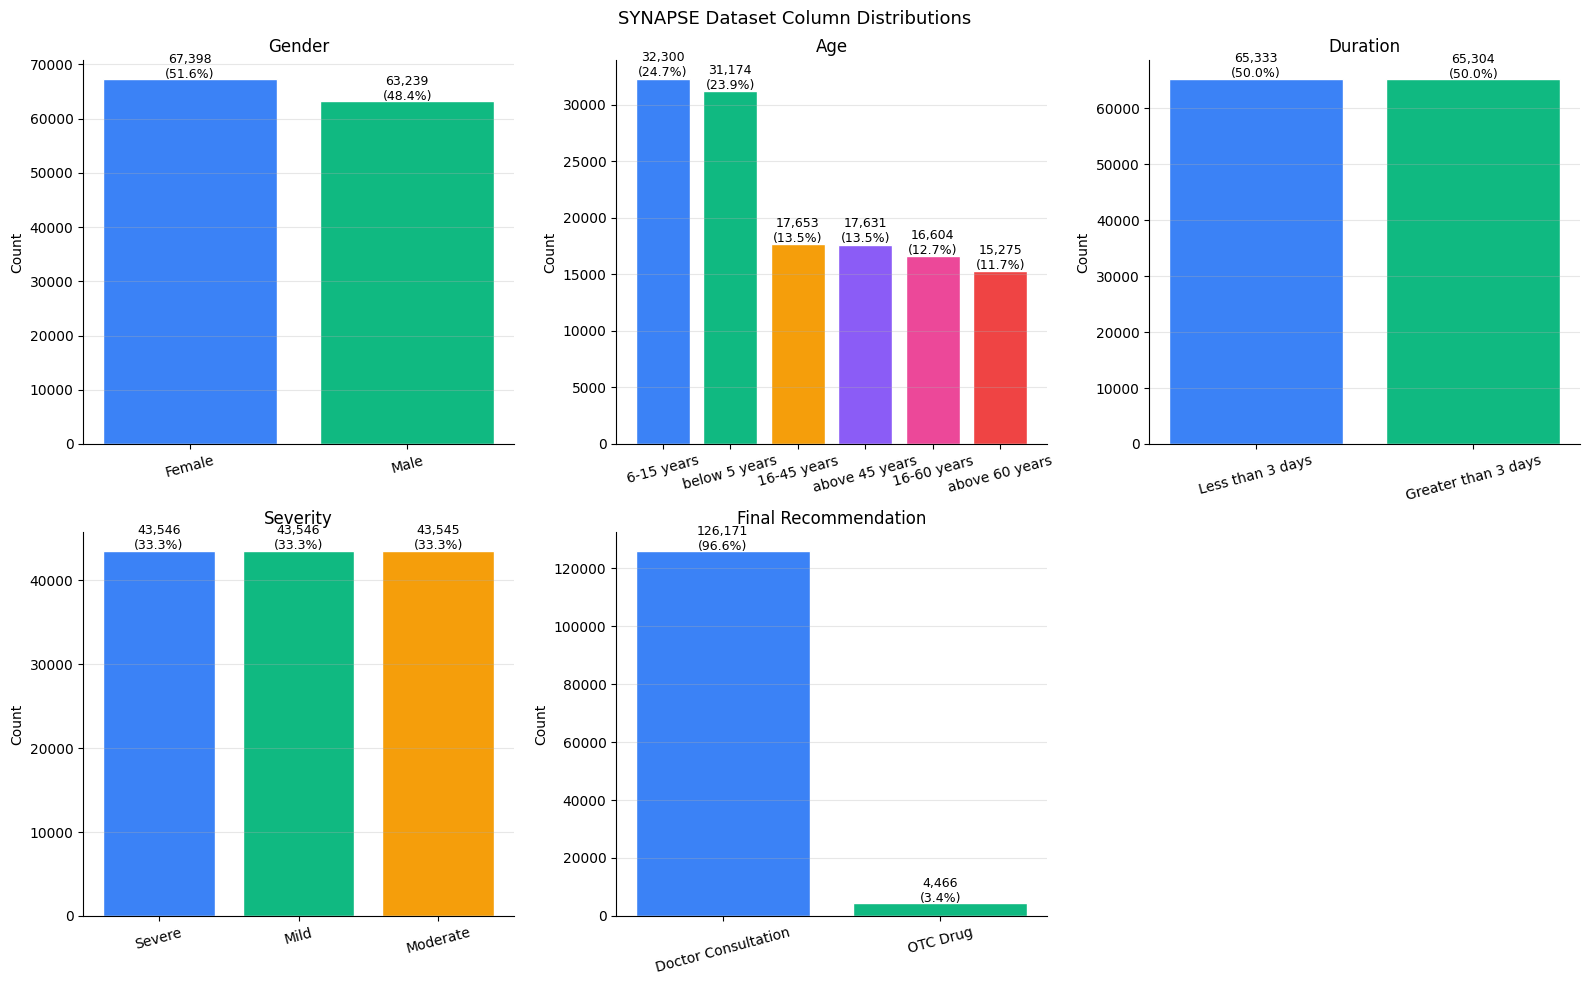

In [45]:
# plot column distributions
cols_to_plot = ['Gender', 'Age', 'Duration', 'Severity', 'Final Recommendation']
bar_colors = ['#3B82F6', '#10B981', '#F59E0B', '#8B5CF6', '#EC4899', '#EF4444', '#06B6D4']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SYNAPSE Dataset Column Distributions', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    counts = df[col].value_counts()
    colors = bar_colors[:len(counts)]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=9
        )

    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('../results/column_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# check target columns
print("\nFinal Recommendation distribution:")
print(df['Final Recommendation'].value_counts())
print("\nSeverity distribution:")
print(df['Severity'].value_counts())

# conflict rate analysis - checking if severity/final rec are learnable targets
dup_fr = df.groupby(['Symptoms', 'Age', 'Duration', 'Gender'])['Final Recommendation'].nunique()
conflict_rate_fr = (dup_fr > 1).sum() / len(dup_fr) * 100
print(f"\nFinal Recommendation conflict rate: {conflict_rate_fr:.1f}%")

dup_sev = df.groupby(['Symptoms', 'Age', 'Duration', 'Gender'])['Severity'].nunique()
conflict_rate_sev = (dup_sev > 1).sum() / len(dup_sev) * 100
print(f"Severity conflict rate: {conflict_rate_sev:.1f}%")


Final Recommendation distribution:
Final Recommendation
Doctor Consultation    126171
OTC Drug                 4466
Name: count, dtype: int64

Severity distribution:
Severity
Severe      43546
Mild        43546
Moderate    43545
Name: count, dtype: int64

Final Recommendation conflict rate: 7.2%
Severity conflict rate: 99.5%


**Observation:** severity has 99.5% conflict rate so its not learnable as a target.
Using Final_Recommendation instead, severity will be used as input feature

In [47]:
# clean columns
df.columns = df.columns.str.strip().str.replace(' ', '_')
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

def clean_symptoms(symptom_str):
    """
    Clean symptom string
    :param symptom_str: symptom
    :return: Cleaned symptom string
    """
    # split by comma, strip, replace spaces with underscores
    symptoms = [symptom.strip().lower() for symptom in symptom_str.split(',')]
    return ' '.join(symptoms)

df['symptoms_clean'] = df['Symptoms'].apply(clean_symptoms)

In [48]:
# tfidf vectorise symptoms
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000,
    min_df=5,
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(df['symptoms_clean'])
print(f"\ntfidf matrix shape: {X_tfidf.shape}")
print(f"sparsity: {(1 - X_tfidf.nnz/(X_tfidf.shape[0]*X_tfidf.shape[1]))*100:.1f}%")



tfidf matrix shape: (130637, 3000)
sparsity: 99.3%


#### Feature Engineering: TF-IDF Vectorisation

Symptoms are vectorised using TF-IDF with bigrams to capture two-word clinical
phrases like "chest pain". min_df=5 filters noise including cross-boundary bigrams
from comma-separated symptom strings. The sparsity output confirms the high-dimensional
sparse feature space, justifying selection of sparse-data-suited classifiers over
tree-based approaches like Random Forest.

In [49]:
# encode demographic features
gender_map = {'Male': 0, 'Female': 1}
duration_map = {'Less than 3 days': 0, 'Greater than 3 days': 1}
age_map = {
    'below 5 years': 0, '6-15 years': 1,
    '16-45 years': 2, '16-60 years': 2,
    'above 45 years': 3, 'above 60 years': 4
}
severity_map = {'Mild': 0, 'Moderate': 1, 'Severe': 2}

gender_enc = df['Gender'].map(gender_map).fillna(0)
duration_enc = df['Duration'].map(duration_map).fillna(0)
age_enc = df['Age'].str.strip().map(age_map).fillna(2) # default to 16-45 if unknown
severity_enc = df['Severity'].map(severity_map).fillna(1)

print(f"\ngender unmapped: {gender_enc.isna().sum()}")
print(f"duration unmapped: {duration_enc.isna().sum()}")
print(f"age unmapped: {age_enc.isna().sum()}")


gender unmapped: 0
duration unmapped: 0
age unmapped: 0


In [50]:
# combine tfidf + demographics + severity into one sparse matrix
demo = scipy.sparse.csr_matrix(
    np.column_stack([gender_enc, duration_enc, age_enc])
)
sev_feat = scipy.sparse.csr_matrix(severity_enc.values.reshape(-1, 1))
X_combined = scipy.sparse.hstack([X_tfidf, demo, sev_feat])

print(f"\nfinal feature matrix: {X_combined.shape}")
print("3000 tfidf + 3 demographic + 1 severity context = 3004 features")


final feature matrix: (130637, 3004)
3000 tfidf + 3 demographic + 1 severity context = 3004 features


In [51]:
# encode target variable
le = LabelEncoder()
le.fit(['Doctor Consultation', 'OTC Drug'])
y = le.transform(df['Final_Recommendation'])

print(f"\nlabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("class distribution:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    count = (y == enc).sum()
    print(f"  {cls}: {count:,} ({count/len(y)*100:.1f}%)")


label encoding: {'Doctor Consultation': 0, 'OTC Drug': 1}
class distribution:
  Doctor Consultation: 126,171 (96.6%)
  OTC Drug: 4,466 (3.4%)


In [52]:
# stratified 70/10/20 split
# split off test first so it never touches preprocessing
X_tv, X_test, y_tv, y_test = train_test_split(
    X_combined, y, test_size=0.20, random_state=42, stratify=y
)
# 0.125 of 80% = 10% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.125, random_state=42, stratify=y_tv
)

print(f"\ntrain: {X_train.shape[0]:,}")
print(f"val: {X_val.shape[0]:,}")
print(f"test: {X_test.shape[0]:,}")


train: 91,445
val: 13,064
test: 26,128


In [53]:
# sanity check - lr before smote to verify target is learnable
# and to see class imbalance effect on otc precision
print("\nsanity check - lr before smote:")
lr_test = LogisticRegression(max_iter=6000, class_weight='balanced', solver='saga', random_state=42)
lr_test.fit(X_train, y_train)
val_pred = lr_test.predict(X_val)
print(f"val accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"val weighted f1: {f1_score(y_val, val_pred, average='weighted'):.4f}")
print(classification_report(y_val, val_pred, target_names=le.classes_))


sanity check - lr before smote:
val accuracy: 0.8999
val weighted f1: 0.9268
                     precision    recall  f1-score   support

Doctor Consultation       1.00      0.90      0.95     12617
           OTC Drug       0.25      0.99      0.40       447

           accuracy                           0.90     13064
          macro avg       0.63      0.94      0.67     13064
       weighted avg       0.97      0.90      0.93     13064



/Users/yoshani/Documents/Academic/TIR/Implementation/p2/adaptive-clinical-assistant-saca/backend/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**Observation:** OTC Drug Precision is 0.48, meaning 52% of OTC predictions
are incorrect. This clinically dangerous result justifies applying SMOTE to
the training set to improve minority class learning before full model training.

In [54]:
# apply smote to training set only
print(f"before smote: {Counter(y_train)}")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"after smote: {Counter(y_train_bal)}")
print(f"train size: {len(y_train):,} -> {len(y_train_bal):,}")

before smote: Counter({0: 88319, 1: 3126})
after smote: Counter({0: 88319, 1: 88319})
train size: 91,445 -> 176,638


**Observation:** SMOTE is applied exclusively to the training set to address the
96.6%/3.4% class imbalance. The training set grows from 91,445 to 176,638 samples
as synthetic OTC Drug cases are generated through feature space interpolation.
The validation and test sets retain the original class distribution to ensure
evaluation reflects real-world conditions.

In [55]:
# save artefacts
os.makedirs('../models', exist_ok=True)
os.makedirs('../data_processed', exist_ok=True)

scipy.sparse.save_npz('../data_processed/X_train.npz', X_train_bal)
scipy.sparse.save_npz('../data_processed/X_val.npz', X_val)
scipy.sparse.save_npz('../data_processed/X_test.npz', X_test)
np.save('../data_processed/y_train.npy', y_train_bal)
np.save('../data_processed/y_val.npy', y_val)
np.save('../data_processed/y_test.npy', y_test)

with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open('../models/severity_map.pkl', 'wb') as f:
    pickle.dump(severity_map, f)

print("\nsaved:")
print(" data_processed/ - train/val/test splits")
print(" models/tfidf_vectorizer.pkl")
print(" models/label_encoder.pkl")
print(" models/severity_map.pkl")

print("\nsummary:")
print(f" dataset: SYNAPSE {df.shape[0]:,} rows")
print(" target: Final_Recommendation (binary)")
print(f" features: {X_combined.shape[1]} total")
print(f" train (balanced): {len(y_train_bal):,}")
print(f" val: {len(y_val):,}")
print(f" test: {len(y_test):,}")


saved:
 data_processed/ - train/val/test splits
 models/tfidf_vectorizer.pkl
 models/label_encoder.pkl
 models/severity_map.pkl

summary:
 dataset: SYNAPSE 130,637 rows
 target: Final_Recommendation (binary)
 features: 3004 total
 train (balanced): 176,638
 val: 13,064
 test: 26,128
